Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. Rozważ zbiór danych [Air Quality](https://archive.ics.uci.edu/dataset/360/air+quality)
1. [0-3 pkt] Dokonaj wstępnego przetwarzania danych. Skomentuj poszczególne kroki i podjęte decyzje. **Uwagi**: 
   1. kluczowe jest zapoznanie się z opisem zbioru danych
   1. nie interesuje nas tu zależność czasowa - nie traktujemy tego zbioru jako serii czasowej. Jednak rozważ użycie miesiąca jako zmiennej kategorycznej
   1. jaką inną zmienną powinniśmy wyłączyć z analizy? Dlaczego?
   1. jako zmienną zależną (*target*) rozważ sumę koncentracji poszczególnych związków (ozn. `GT`). Czy sumę liczymy przed czy po skalowaniu cech?
1. [0-2 pkt] Użyj:
   1. modelu liniowego
   1. modelu liniowego z regularyzcją L1
   1. modelu liniowego z regularyzcją L2
   1. regresji Hubera
1. [0-2 pkt] Porównaj poszczególne modele dla domyślnych parametrów oraz różnych wartości regularyzacji (użyj [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html))
1. [0-1 pkt] Skomentuj uzyskane wyniki m.in. odnośnie wartości RMSE i MAE oraz czasu treningu
1. [0-1 pkt] Zbadaj wpływ wstępnego przetwarzania danych (np. wpływu skorelowanych cech, usuwania zmiennych katagorycznych, normalizacji) na wyniki. W tym celu możesz użyć klasy [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
1. [0-1 pkt] Zwizualizuj wartości parametrów, porównując wszystkie modele razem. Jak wybór parametrów wpływa na osiągi modelu?
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**

# Krok 0. Import bibliotek

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from sklearn.compose import ColumnTransformer

# Krok 1. Pobranie danych z biblioteki 

In [62]:
air_quality = fetch_ucirepo(id=360) 
  
X = air_quality.data.features 
  
print(air_quality.metadata) 
  
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

# Krok 2. Preprocessing danych

In [63]:
# zmiana brakujących wartości z -200 (informacja z dokumentacji) na NaN
X.replace(-200, np.nan, inplace=True)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003.0,NaN,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [64]:
# Liczba braków w każdej kolumnie
print(X.isna().sum())

# Procent braków w każdej kolumnie
print(X.isna().mean() * 100)

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64
Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
C6H6(GT)          3.911510
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64


Widać duży procent brakujących danych dla cechy `NMHC(GT)` więc możemy usunąć ją z naszego datasetu

In [65]:
X.drop(columns=["NMHC(GT)"], inplace=True)
X

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


Dodatkowo mamy rozważyć miesiące jako zmienną kategoryczną w naszym datasetcie. Niestety, ale dokumentacja wprowadza nas w błąd i daty nie są w formacie DD/MM/YYYY tylko MM/DD/YYYY co widać z powyższej tabelki. Wiemy też z treści zadania, że nie mamy rozpatrywać dat oraz godzin w naszym modelu, więc możemy te dwie cechy usunąć, a dodać cechę miesięcy, która później zostanie skategoryzowana z użyciem OneHotEncoding

In [66]:
X.drop(columns=["Time"], inplace=True)
dates = X.pop("Date")
months = dates.str.split("/", expand=True)[0].astype(int)
X["Month"] = months

In [67]:
X, X.shape

(      CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
 0        2.6       1360.0      11.9         1046.0    166.0        1056.0   
 1        2.0       1292.0       9.4          955.0    103.0        1174.0   
 2        2.2       1402.0       9.0          939.0    131.0        1140.0   
 3        2.2       1376.0       9.2          948.0    172.0        1092.0   
 4        1.6       1272.0       6.5          836.0    131.0        1205.0   
 ...      ...          ...       ...            ...      ...           ...   
 9352     3.1       1314.0      13.5         1101.0    472.0         539.0   
 9353     2.4       1163.0      11.4         1027.0    353.0         604.0   
 9354     2.4       1142.0      12.4         1063.0    293.0         603.0   
 9355     2.1       1003.0       9.5          961.0    235.0         702.0   
 9356     2.2       1071.0      11.9         1047.0    265.0         654.0   
 
       NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH 

Jako zmienną `y` uznałem, że wybiorę sumę z wszystkich cech, które mają dopisek `GT` w swojej nazwie

In [68]:
columns_for_y = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

Usuwamy wiersze, gdzie brakuje nam wartości w kolumnach, które będą tworzyć nam `y`

In [69]:
X.dropna(subset=columns_for_y, inplace=True)
X

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,3
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,3
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,3
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,3
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,4
9353,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,4
9354,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,4
9355,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,4


Wypiszmy liczbę oraz procent wartości NaN per cecha

In [70]:
# Liczba braków w każdej kolumnie
print(X.isna().sum())

# Procent braków w każdej kolumnie
print(X.isna().mean() * 100)
X.shape

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Month            0
dtype: int64
CO(GT)           0.0
PT08.S1(CO)      0.0
C6H6(GT)         0.0
PT08.S2(NMHC)    0.0
NOx(GT)          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
PT08.S5(O3)      0.0
T                0.0
RH               0.0
AH               0.0
Month            0.0
dtype: float64


(6941, 13)

Wygląda na to, że udało się uzyskać dataset, gdzie każdy rekord ma wartość dla każdej cechy, co jest bardzo pożądane, bo nie musimy imputować danych i nasz model będzie się opierał na dokładnych danych, w żaden sposób nie spreparowanych przez nas

Tworzymy nową cechę - `y` która będzie sumą wszystkich 4 cech, które wyznaczają `y`. Następnie zapisujemy to do osobnej zmiennej. Sumowanie zawsze robimy przed przekształcaniem danych, aby zachować rzeczywiste proporcje wartości wchodzących w skład sumy

In [71]:
X['y'] = X[columns_for_y].sum(axis=1)
X

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month,y
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,3,293.5
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,3,206.4
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,3,256.2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,3,305.4
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,3,255.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,4,678.6
9353,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,4,545.8
9354,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,4,482.8
9355,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,4,402.6


In [72]:
X.drop(columns=columns_for_y, inplace=True)
y = X.pop("y")

In [73]:
X.shape, len(y)

((6941, 9), 6941)

Wygląda na to, że preprocessing się udał i możemy przejść do kolejnego kroku

# Krok 3. Podział danych oraz ich przekształcenie

Dla cech kategorycznych (miesięcy) użyjemy `OneHotEncoding`, dla reszty `StandardScaler`

In [74]:
categorical_features = ['Month']
numeric_features = X.columns.difference(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

Podział na zbiór treningowy oraz testowy

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Przekształcenia zbiorów treningowych i testowych wykorzystując `ColumnTransformer`. Zanim to zrobiłem, postanowiłem zapisać nieprzekształcone wersje danych traningowych oraz testowych, aby później sprawdzić, jak zmiana danych (przekszałcenie) na nie wpływa

In [76]:
X_train_not_scaled = X_train.copy()
X_test_not_scaled = X_test.copy()

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Krok 4. Trening i ewaluacja

In [77]:
import time
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_train, y_train, X_test, y_test, name, variant):
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Model: {name}")
    print(f"Wariant: {variant}")
    print(f"RMSE: {round(rmse, 4)}")
    print(f"MAE: {round(mae, 4)}")
    print(f"Training Time: {round(training_time, 4)} seconds")

    return {
        "Model": name,
        "Wariant": variant,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "Train Time [s]": round(training_time, 4)
    }

Regresja liniowa

In [78]:
linear_reg = LinearRegression()
results = evaluate_model(linear_reg, X_train, y_train, X_test, y_test, "Linear", "Przekształcone")

Model: Linear
Wariant: Przekształcone
RMSE: 89.9415
MAE: 64.9765
Training Time: 0.0024 seconds


Regresja liniowa z regularyzacją L1

In [79]:
from sklearn.linear_model import Lasso

lasso = Lasso()
results_lasso = evaluate_model(lasso, X_train, y_train, X_test, y_test, "Lasso", "Przekształcone")

Model: Lasso
Wariant: Przekształcone
RMSE: 90.9379
MAE: 66.2149
Training Time: 0.0016 seconds


Regresja liniowa z regularyzacją L2

In [80]:
from sklearn.linear_model import Ridge

ridge = Ridge()
results_ridge = evaluate_model(ridge, X_train, y_train, X_test, y_test, "Ridge", "Przekształcone")

Model: Ridge
Wariant: Przekształcone
RMSE: 89.8975
MAE: 64.9917
Training Time: 0.001 seconds


Regresja Hubera

In [81]:
from sklearn.linear_model import HuberRegressor

huber = HuberRegressor()
results_huber = evaluate_model(huber, X_train, y_train, X_test, y_test, "Huber", "Przekształcone")

Model: Huber
Wariant: Przekształcone
RMSE: 91.8915
MAE: 63.6235
Training Time: 0.0456 seconds


Teraz wykorzystamy `GridSearchCV` dla L1, L2 oraz Huber w celu wyznaczenia optymalnych parametrów

In [82]:
from sklearn.model_selection import GridSearchCV

lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=5)
results_lasso_grid = evaluate_model(lasso_grid, X_train, y_train, X_test, y_test, "Lasso + GridSearchCV", "Przekształcone")
best_alpha_lasso_grid = lasso_grid.best_params_['alpha']
print(f"Best alpha for Lasso GridSearchCV: {best_alpha_lasso_grid}")

Model: Lasso + GridSearchCV
Wariant: Przekształcone
RMSE: 89.9306
MAE: 64.9842
Training Time: 0.0529 seconds
Best alpha for Lasso GridSearchCV: 0.01


In [83]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5)
results_ridge_grid = evaluate_model(ridge_grid, X_train, y_train, X_test, y_test, "Ridge + GridSearchCV", "Przekształcone")
best_alpha_ridge_grid = ridge_grid.best_params_['alpha']
print(f"Best alpha for Ridge GridSearchCV: {best_alpha_ridge_grid}")


Model: Ridge + GridSearchCV
Wariant: Przekształcone
RMSE: 89.8975
MAE: 64.9917
Training Time: 0.0181 seconds
Best alpha for Ridge GridSearchCV: 1


In [84]:
huber_params = {
    'epsilon': [1.1, 1.35, 1.5],
    'alpha': [0.0001, 0.001, 0.01]
}
huber_grid = GridSearchCV(HuberRegressor(max_iter=2000), huber_params, cv=5)
results_huber_grid = evaluate_model(huber_grid, X_train, y_train, X_test, y_test, "Huber + GridSearchCV", "Przekształcone")
best_alpha_huber_grid = huber_grid.best_params_['alpha']
print(f"Best alpha for Huber GridSearchCV: {best_alpha_huber_grid}")

Model: Huber + GridSearchCV
Wariant: Przekształcone
RMSE: 91.5679
MAE: 63.662
Training Time: 0.8499 seconds
Best alpha for Huber GridSearchCV: 0.0001


W tym momencie bierzemy dane nieprzekształcone i dla nich wyznaczamy regresję (dokładnie takie same modele jak dla danych przekształconych)

In [85]:
linear_reg = LinearRegression()
results_not_scaled = evaluate_model(linear_reg, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Linear", "Nieprzekształcone")
print()

lasso = Lasso()
results_lasso_not_scaled = evaluate_model(lasso, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Lasso", "Nieprzekształcone")
print()

ridge = Ridge()
results_ridge_not_scaled = evaluate_model(ridge, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Ridge", "Nieprzekształcone")
print()

huber = HuberRegressor()
results_huber_not_scaled = evaluate_model(huber, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Huber", "Nieprzekształcone")
print()

lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid_not_scaled = GridSearchCV(Lasso(), lasso_params, cv=5)
results_lasso_grid_not_scaled = evaluate_model(lasso_grid_not_scaled, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Lasso + GridSearchCV", "Nieprzekształcone")
best_alpha_lasso_grid_not_scaled = lasso_grid_not_scaled.best_params_['alpha']
print(f"Best alpha for Lasso GridSearchCV: {best_alpha_lasso_grid_not_scaled}\n")

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid_not_scaled = GridSearchCV(Ridge(), ridge_params, cv=5)
results_ridge_grid_not_scaled = evaluate_model(ridge_grid_not_scaled, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Ridge + GridSearchCV", "Nieprzekształcone")
best_alpha_ridge_grid_not_scaled = ridge_grid_not_scaled.best_params_['alpha']
print(f"Best alpha for Ridge GridSearchCV: {best_alpha_ridge_grid_not_scaled}\n")

huber_params = {
    'epsilon': [1.1, 1.35, 1.5],
    'alpha': [0.0001, 0.001, 0.01]
}
huber_grid_not_scaled = GridSearchCV(HuberRegressor(max_iter=2000), huber_params, cv=5)
results_huber_grid_not_scaled = evaluate_model(huber_grid_not_scaled, X_train_not_scaled, y_train, X_test_not_scaled, y_test, "Huber + GridSearchCV", "Nieprzekształcone")
best_alpha_huber_grid_not_scaled = huber_grid_not_scaled.best_params_['alpha']
print(f"Best alpha for Huber GridSearchCV: {best_alpha_huber_grid_not_scaled}")

Model: Linear
Wariant: Nieprzekształcone
RMSE: 93.0873
MAE: 67.4951
Training Time: 0.0016 seconds

Model: Lasso
Wariant: Nieprzekształcone
RMSE: 93.3894
MAE: 67.9809
Training Time: 0.0013 seconds

Model: Ridge
Wariant: Nieprzekształcone
RMSE: 93.0871
MAE: 67.496
Training Time: 0.0007 seconds

Model: Huber
Wariant: Nieprzekształcone
RMSE: 96.9314
MAE: 67.0578
Training Time: 0.0213 seconds

Model: Lasso + GridSearchCV
Wariant: Nieprzekształcone
RMSE: 93.0871
MAE: 67.5083
Training Time: 0.0379 seconds
Best alpha for Lasso GridSearchCV: 0.1

Model: Ridge + GridSearchCV
Wariant: Nieprzekształcone
RMSE: 93.0895
MAE: 67.5057
Training Time: 0.0244 seconds
Best alpha for Ridge GridSearchCV: 10



/Users/blazej/Desktop/Studies/Year 3/Semester 6/Foundations of Machine Teaching/.venv/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Model: Huber + GridSearchCV
Wariant: Nieprzekształcone
RMSE: 97.0618
MAE: 67.0054
Training Time: 2.0805 seconds
Best alpha for Huber GridSearchCV: 0.0001


Trening wykonany, więc możemy przejść teraz do wykresów oraz podsumowania otrzymanych wyników

# Krok 5. Wykresy oraz podsumowanie

In [100]:
results_scaled_df = pd.DataFrame([
    results,
    results_lasso,
    results_ridge,
    results_huber,
    results_lasso_grid,
    results_ridge_grid,
    results_huber_grid,
])

results_not_scaled_df = pd.DataFrame([
    results_not_scaled,
    results_lasso_not_scaled,
    results_ridge_not_scaled,
    results_huber_not_scaled,
    results_lasso_grid_not_scaled,
    results_ridge_grid_not_scaled,
    results_huber_grid_not_scaled,
])

results_all = pd.concat([results_scaled_df, results_not_scaled_df], ignore_index=True)


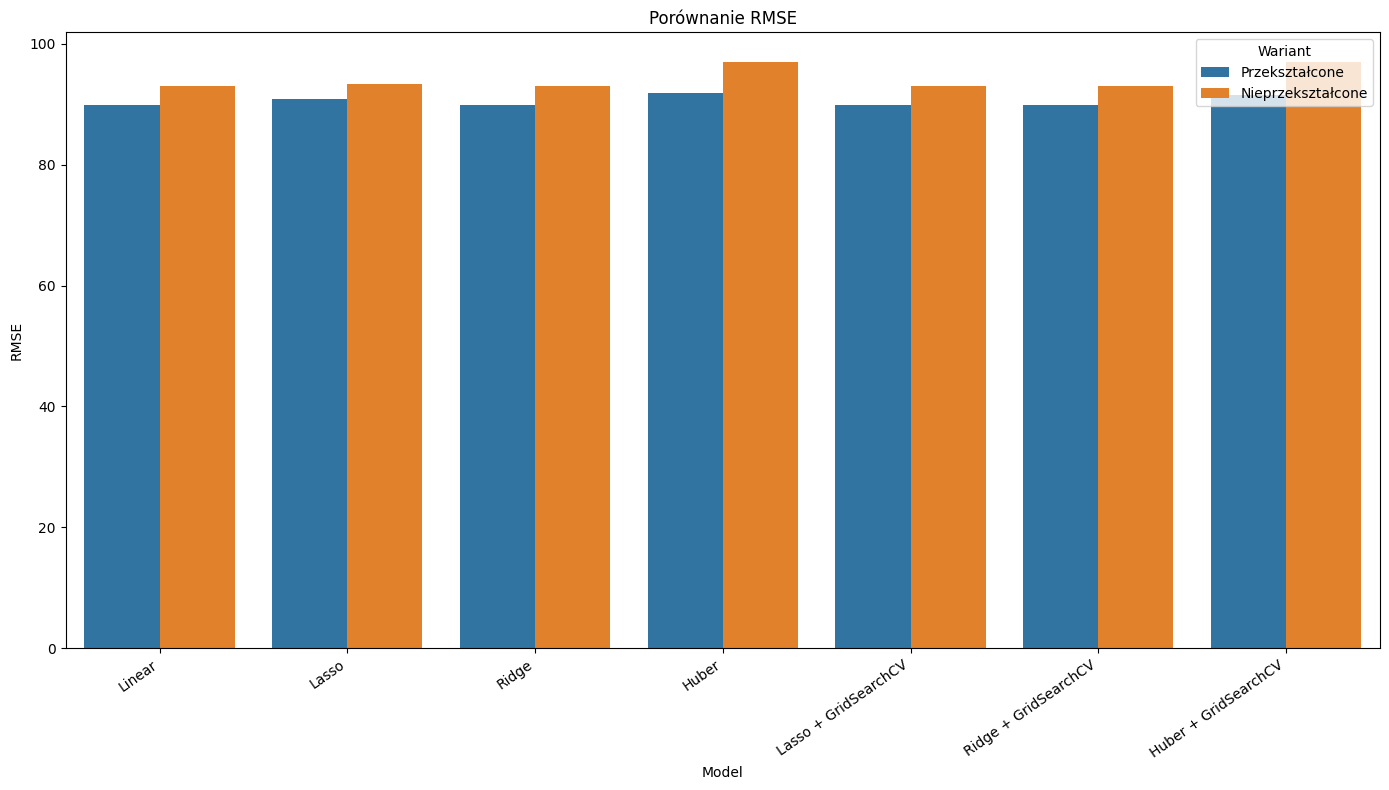

In [101]:
plot_df = results_all.copy()

model_order = [
    "Linear",
    "Lasso",
    "Ridge",
    "Huber",
    "Lasso + GridSearchCV",
    "Ridge + GridSearchCV",
    "Huber + GridSearchCV",
]

plt.figure(figsize=(14, 8))
sns.barplot(
    data=plot_df,
    x="Model",
    y="RMSE",
    hue="Wariant",
    order=model_order,
    hue_order=["Przekształcone", "Nieprzekształcone"],
)
plt.title("Porównanie RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Z powyższego wykresu możemy wyciągnąć prosty wniosek - brak przekształcenia danych negatywnie wpływa na wyniki modelu, niezależnie czy użyjemy regularyzacji czy nie, czy z optymalizatorem parametrów czy bez. W każdym przypadku modele z nieprzkeształconymi danymi miały większe RMSE. Porównując jednak jedynie modele dla przekształconych danych widać niewielkie różnice pomiędzy RMSE poszczególnych modeli. Najmniejsze miała regresja Hubera `89.8915`, a największe Huber + GridSearchCV `91.5679`. Różnice te pokazują, że mamy taki zbiór testowy, który prawie że domyślnie daje dość sensowne wyniki (dla zwykłej regresji to `89.9415`)

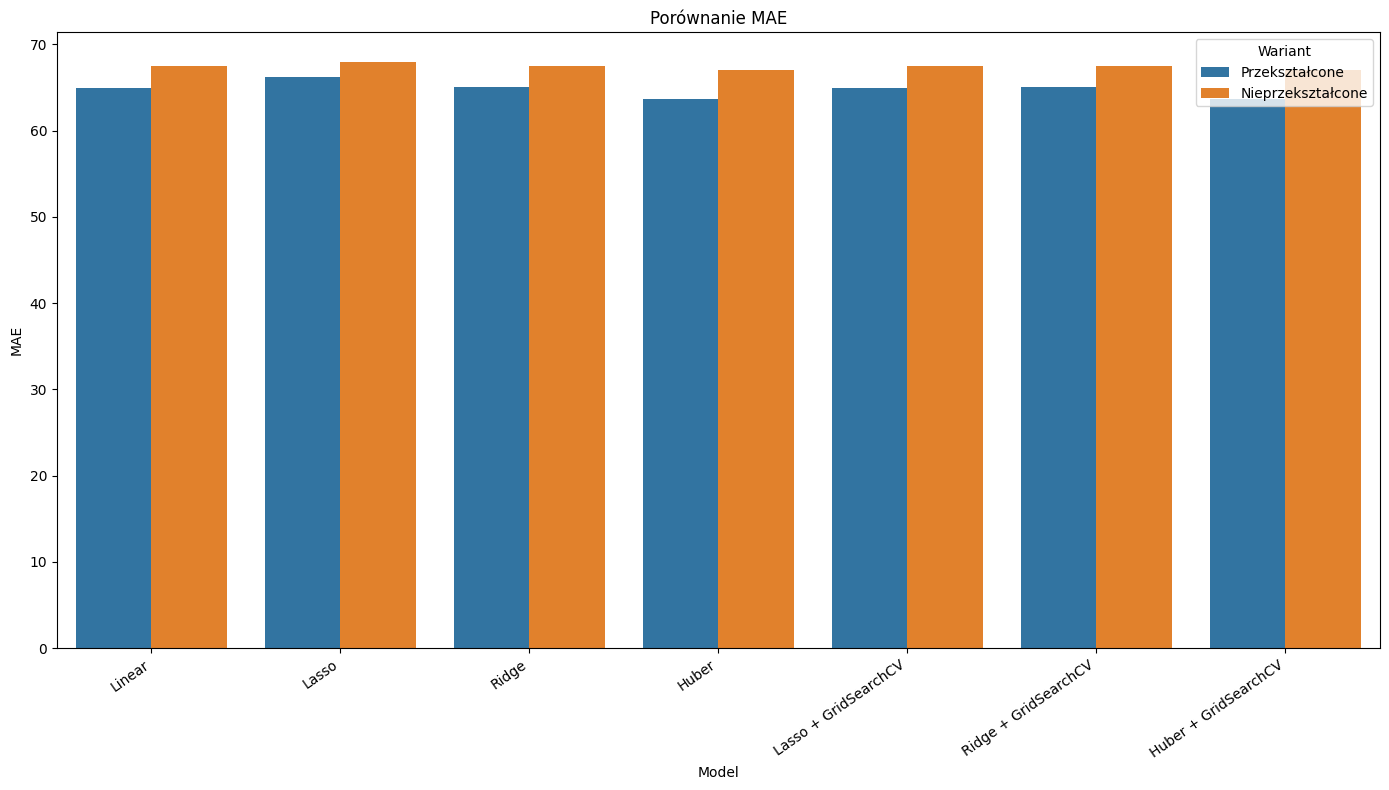

In [102]:
plot_df = results_all.copy()

model_order = [
    "Linear",
    "Lasso",
    "Ridge",
    "Huber",
    "Lasso + GridSearchCV",
    "Ridge + GridSearchCV",
    "Huber + GridSearchCV",
]

plt.figure(figsize=(14, 8))
sns.barplot(
    data=plot_df,
    x="Model",
    y="MAE",
    hue="Wariant",
    order=model_order,
    hue_order=["Przekształcone", "Nieprzekształcone"],
)
plt.title("Porównanie MAE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Widać tutaj podobny przypadek co dla `RMSE` - modele trenowane na danych przekształconych za każdym razem zwracają wyższe wartości `MAE`. Potwierdza to fakt, iż przekształcanie danych, czyli np `OneHotEncoding`, `Normalizacja`, `Skalowanie` ma sens i pozytywnie wpływa na działanie modelu. Opierając nasz obserwację tylko na modelach trenowanych na danych przekształconych widzimy, że najniższą wartość mamy dla regresji `Hubera` (`63.6235`), a najwyższy dla `regresji liniowej z regularyzacją L2` (`66.2149`). Nadal różnice pomiędzy najgorszym a najlepszym wynikiem są dość niskie, a domyślna regresja liniowa osiągnęła MAE na poziomie `64.9765`

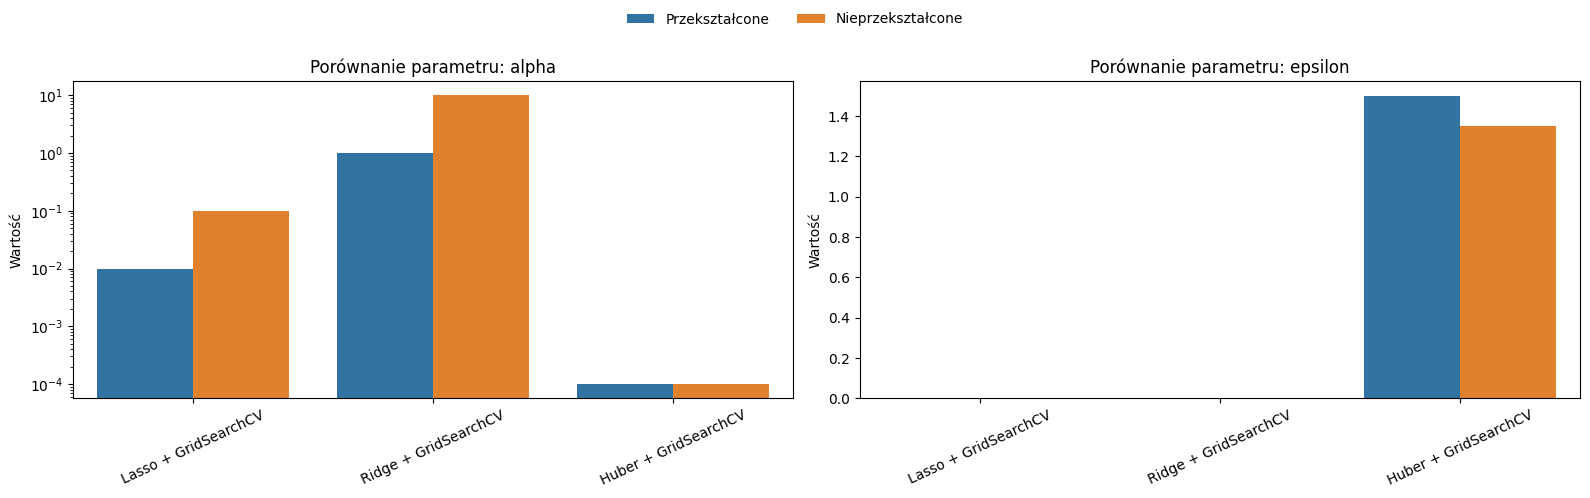

In [103]:
best_params_by_variant = {
    "Przekształcone": {
        "Lasso + GridSearchCV": {"alpha": best_alpha_lasso_grid, "epsilon": np.nan},
        "Ridge + GridSearchCV": {"alpha": best_alpha_ridge_grid, "epsilon": np.nan},
        "Huber + GridSearchCV": huber_grid.best_params_,
    },
    "Nieprzekształcone": {
        "Lasso + GridSearchCV": {"alpha": best_alpha_lasso_grid_not_scaled, "epsilon": np.nan},
        "Ridge + GridSearchCV": {"alpha": best_alpha_ridge_grid_not_scaled, "epsilon": np.nan},
        "Huber + GridSearchCV": huber_grid_not_scaled.best_params_,
    },
}

hyperparams_df = pd.DataFrame(
    [
        {
            "Model": model,
            "Wariant": variant,
            "alpha": params.get("alpha", np.nan),
            "epsilon": params.get("epsilon", np.nan),
        }
        for variant, models in best_params_by_variant.items()
        for model, params in models.items()
    ]
)

model_order = [
    "Lasso + GridSearchCV",
    "Ridge + GridSearchCV",
    "Huber + GridSearchCV",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, parametr in zip(axes, ["alpha", "epsilon"]):
    subset = hyperparams_df[["Model", "Wariant", parametr]].dropna()
    subset = subset.rename(columns={parametr: "Wartość"})

    sns.barplot(
        data=subset,
        x="Model",
        y="Wartość",
        hue="Wariant",
        order=model_order,
        hue_order=["Przekształcone", "Nieprzekształcone"],
        ax=ax,
    )
    ax.set_title(f"Porównanie parametru: {parametr}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    if parametr == "alpha":
        ax.set_yscale("log")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Jak widać z powyższych dwóch wykresów, w przypadku parametru `alpha` znów dla danych nieprzekształconych jest ona mniejsza, co nie oznacza, że lepsza. Niski poziom alpha może powodować łatiwjeszy overfitting modelu. Ciekawa sytuacja wystąpiła dla regresji Hubera, gdzie zarówno dla przekszałconych, jak i nieprzekszatłconych danych mamy tą samą wartość alpha

`epsilon` do drugi parametr w regresji, więc występuje on tylko w przypadku `ElasticNet` oraz `Huber`. Ciekawym jest to, że dla danych nieprzekształconych jest on mniejszy. Może być to właśnie tym spowodowane, ponieważ im mniejszy epsilon, tym model szybciej będzie podejrzewać, że uzyskany błąd jest podejrzany. Mimo to uważam, że osiągnięte wartości alpha i epsilon dla `Hubera` są bardzo dobre

# Podsumowanie

Patrząc na uzyskane wyniki można w łatwy sposób wybrać regresję `Hubera` za najlepszy model dla tego problemu. Jednakże porównanie jego wyników, do wyników modeli `LASSO`, `Ridge`, zwykłej regularyzacji oraz ich opcji z użyciem `GridSearchCV` nie daje wielkiej różnicy. Można rzecz, że patrząc po wynikach najzwyklejszej regresji liniowej, wybranie jej jako naszego modelu będzie dobrym wyborem. Wpływ na to mogła mieć niezbyt duża liczba cech, przez co nasz model nie jest aż tak bardzo wielowymiarowy. Ten zbiór danych pokazuje, że regresja, mimo swej prostoty potrafi dalej być użytecznym modelem uczenia maszynowego, a regularyzacje nie zawsze muszę być game-changerem dla problemu